In [704]:
# imports
!pip install tabulate
import math
import tabulate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [510]:
# load data
data=pd.read_csv("experiment_results.csv")
data.head(5)

,Subject,Time,Defect isolated,Defects detected,Treatment,Program
0,S1,145,2,2,Testing,Counter
1,S2,132,1,1,Testing,Counter
2,S3,116,4,4,Testing,Correlation
3,S4,134,0,0,Testing,Counter
4,S5,132,0,0,Testing,Counter


### Figure 1. Boxplot of detected defects per program and per technique.

In [512]:
Count_Detect = data[data["Program"] == "Counter"]["Defects detected"]
Corr_Detect = data[data["Program"] == "Correlation"]["Defects detected"]
Test_Detect = data[data["Treatment"] == "Testing"]["Defects detected"]
Inspect_Detect = data[data["Treatment"] == "Inspection"]["Defects detected"]

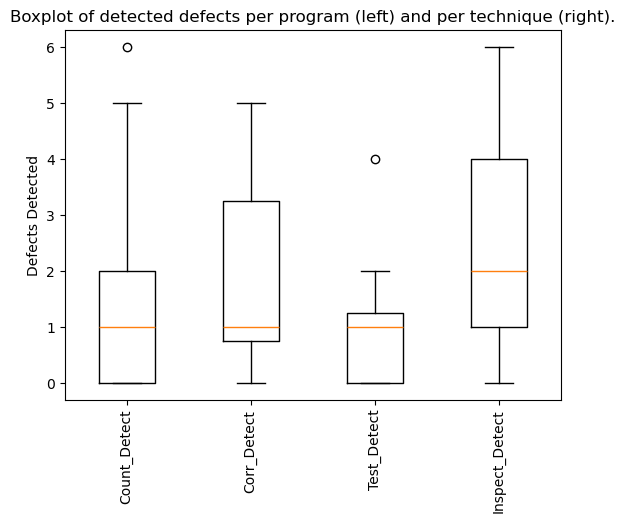

In [513]:
plt.boxplot(
    [Count_Detect,Corr_Detect,Test_Detect,Inspect_Detect],
    tick_labels=["Count_Detect", "Corr_Detect", "Test_Detect", "Inspect_Detect"]
)
plt.title("Boxplot of detected defects per program (left) and per technique (right).")
plt.ylabel("Defects Detected")
plt.xticks(rotation=90)
plt.show()

### Figure 2. Boxplot of isolated defects per program and per technique.

In [515]:
Count_Isolate = data[data["Program"] == "Counter"]["Defect isolated"]
Corr_Isolate = data[data["Program"] == "Correlation"]["Defect isolated"]
Test_Isolate = data[data["Treatment"] == "Testing"]["Defect isolated"]
Inspect_Isolate = data[data["Treatment"] == "Inspection"]["Defect isolated"]

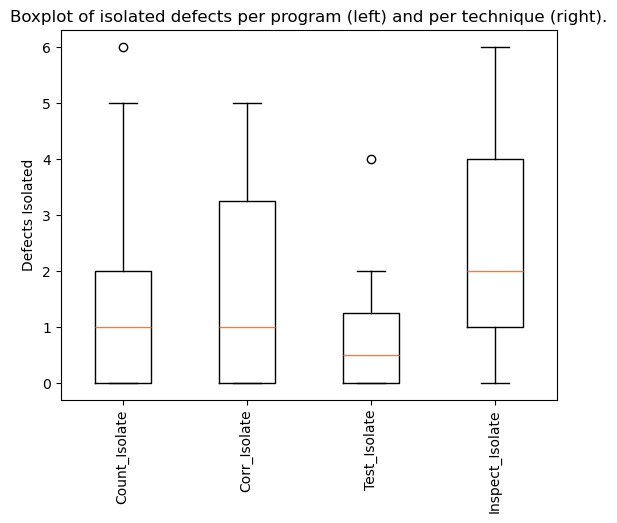

In [516]:
plt.boxplot(
    [Count_Isolate,Corr_Isolate,Test_Isolate,Inspect_Isolate],
    tick_labels=["Count_Isolate", "Corr_Isolate", "Test_Isolate", "Inspect_Isolate"]
)
plt.title("Boxplot of isolated defects per program (left) and per technique (right).")
plt.ylabel("Defects Isolated")
plt.xticks(rotation=90)
plt.show()

### Table 7. Descriptive statistics for defects detected and isolated, grouped per technique

In [518]:
def genrate_summary(grouped,name):
    summary_row = pd.DataFrame({
    ("Median", "Inspection"): [grouped.median().get("Inspection")],
    ("Median", "Testing"): [grouped.median().get("Testing")],
    ("Mean", "Inspection"): [grouped.mean().get("Inspection")],
    ("Mean", "Testing"): [grouped.mean().get("Testing")],
    ("Std. Deviation", "Inspection"): [grouped.std().get("Inspection")],
    ("Std. Deviation", "Testing"): [grouped.std().get("Testing")]
    }, index=[name])

    return summary_row
    

In [519]:
DEFd= genrate_summary(data.groupby("Treatment")["Defects detected"],"DEFd")
DEFi= genrate_summary(data.groupby("Treatment")["Defect isolated"],"DEFi")

data_effect = data.copy()
eff_d = 60 * data["Defect isolated"] / data["Time"]
eff_i = 60 * data["Defects detected"] / data["Time"]

data_effect["Defects detected"] = eff_d
data_effect["Defect isolated"] = eff_i

EFFd= genrate_summary(data_effect.groupby("Treatment")["Defects detected"],"EFFd")
EFFi= genrate_summary(data_effect.groupby("Treatment")["Defect isolated"],"EFFi")

summary_df = pd.concat([DEFd, DEFi,EFFi,EFFd])

summary_df

Median               Mean          Std. Deviation          
     Inspection Testing Inspection  Testing     Inspection   Testing
DEFd   2.000000     1.0   2.550000  0.90000       1.877148  1.071153
DEFi   2.000000     0.5   2.400000  0.85000       1.902906  1.089423
EFFi   1.097744     0.4   1.331775  0.41203       1.046489  0.524613
EFFd   1.093168     0.2   1.252298  0.39203       1.048896  0.532658

### Table 8. Descriptive statistics for defects detected and isolated grouped per program

In [521]:
def genrate_summary_prog(grouped,name):
    summary_row = pd.DataFrame({
    ("Median", "Count"): [grouped.median().get("Counter")],
    ("Median", "Corr"): [grouped.median().get("Correlation")],
    ("Mean", "Count"): [grouped.mean().get("Counter")],
    ("Mean", "Corr"): [grouped.mean().get("Correlation")],
    ("Std. Deviation", "Count"): [grouped.std().get("Counter")],
    ("Std. Deviation", "Corr"): [grouped.std().get("Correlation")]
    }, index=[name])

    return summary_row

In [522]:
DEFd_prog= genrate_summary_prog(data.groupby("Program")["Defects detected"],"DEFd")
DEFi_prog= genrate_summary_prog(data.groupby("Program")["Defect isolated"],"DEFi")

summary_df = pd.concat([DEFd_prog,DEFi_prog])

summary_df

Median       Mean       Std. Deviation          
      Count Corr Count  Corr          Count      Corr
DEFd    1.0  1.0  1.55  1.90       1.731291  1.744163
DEFi    1.0  1.0  1.50  1.75       1.732051  1.743409

### Table 9. Results of Wilcoxon signed rank test for the hypotheses regarding effectiveness and efficiency.

In [524]:
inspec_data = data[data["Treatment"] == "Inspection"]
test_data = data[data["Treatment"] == "Testing"]
inspec_data = inspec_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)


inspec_data_effect = data_effect[data_effect["Treatment"] == "Inspection"]
test_data_effect = data_effect[data_effect["Treatment"] == "Testing"]

inspec_data_effect = inspec_data_effect.reset_index(drop=True)
test_data_effect = test_data_effect.reset_index(drop=True)


In [919]:
def results_summary(name,data1, data2):
    df_wil = pd.DataFrame({"x": data1,"y": data2})
    df_wil["x-y"] = df_wil["x"] -df_wil["y"]
    df_wil["abs"] = df_wil["x-y"].abs()
    df_nonzero = df_wil[df_wil["x-y"] != 0].copy()
   
    df_nonzero = df_nonzero.sort_values(by="abs", ascending=False)
    df_nonzero["rank"] = range(1, len(df_nonzero) + 1)
    df_nonzero["tied_rank"] = stats.rankdata(df_nonzero["abs"], method="average")
    
    df_nonzero["signed rank"] = df_nonzero["rank"] * df_nonzero["x-y"].apply(lambda d: -1 if d < 0 else 1)
    df_nonzero["signed tied_rank"] = df_nonzero["tied_rank"] * df_nonzero["x-y"].apply(lambda d: -1 if d < 0 else 1)

    W_plus = df_nonzero.loc[df_nonzero["signed rank"] > 0, "signed rank"].sum()
    W_minus = abs(df_nonzero.loc[df_nonzero["signed rank"] < 0, "signed rank"].sum())
    w = max(W_plus,W_minus)


    W_plus_tied = df_nonzero.loc[df_nonzero["signed tied_rank"] > 0, "signed tied_rank"].sum()
    W_minus_tied = abs(df_nonzero.loc[df_nonzero["signed tied_rank"] < 0, "signed tied_rank"].sum())
    w_tied= max(W_plus_tied,W_minus_tied)

    expected_value = (len(df_nonzero)*(len(df_nonzero)+1))/4

    standard_deviation = math.sqrt((len(df_nonzero)*(len(df_nonzero)+1)*(2*len(df_nonzero)+1))/24)
    print(expected_value,standard_deviation)


    z = (w- expected_value)/standard_deviation
    z_tied = (w_tied - expected_value)/standard_deviation
    
    # p-value
    qwe, p = stats.wilcoxon(data1, data2, alternative='two-sided', method='approx')
    print(z,z_tied,p)
    differences = [a - b for a, b in zip(data1, data2)]
    
    return df_nonzero
 
'''
    for x in differences:
        if x == 0:
            zero_diff+=1
        elif x < 0:
            rank_low+=1
            sum_rank_low+=abs(x)
        else:
            rank_up+=1
            sum_rank_up+=x
    
    non_zero_differences = [d for d in differences if d != 0]
    n = len(non_zero_differences)
    mean_W = n * (n + 1) / 4
    std_W = math.sqrt((n * (n + 1) * (2 * n + 1))/ 24)
    z = (w - mean_W) / std_W
    
    print(final_summary)
    
    return pd.DataFrame([{
        "Hypothesis": name,
        "Ranks < 0": round(rank_low,0),
        "Zero Differences": zero_diff,
        "Ranks > 0": rank_up,
        "Z-value": round(z, 6),
        "p-value": round(p, 6)
    }])
    
 '''   
    

'\n    for x in differences:\n        if x == 0:\n            zero_diff+=1\n        elif x < 0:\n            rank_low+=1\n            sum_rank_low+=abs(x)\n        else:\n            rank_up+=1\n            sum_rank_up+=x\n    \n    non_zero_differences = [d for d in differences if d != 0]\n    n = len(non_zero_differences)\n    mean_W = n * (n + 1) / 4\n    std_W = math.sqrt((n * (n + 1) * (2 * n + 1))/ 24)\n    z = (w - mean_W) / std_W\n    \n    print(final_summary)\n    \n    return pd.DataFrame([{\n        "Hypothesis": name,\n        "Ranks < 0": round(rank_low,0),\n        "Zero Differences": zero_diff,\n        "Ranks > 0": rank_up,\n        "Z-value": round(z, 6),\n        "p-value": round(p, 6)\n    }])\n    \n '

In [921]:
num1 = results_summary("H_eff-det,0: DEFd_Ins = DEFd_Test",inspec_data["Defects detected"], test_data["Defects detected"])
#num2 = results_summary("H_eff-id,0: DEFi_Ins = DEFi_Test",inspec_data["Defect isolated"], test_data["Defect isolated"])
#num3 = results_summary("H_rate-det,0: EFFd_Ins = EFFd_Test",inspec_data_effect["Defects detected"], test_data_effect["Defects detected"])
#num4 = results_summary("H_eff-id,0: DEFi_Ins = DEFi_Test",inspec_data_effect["Defect isolated"], test_data_effect["Defect isolated"])


#final_summary = pd.concat([num1, num2, num3, num4], ignore_index=True)
num1_sorted = num1.sort_values(by="rank", ascending=False)
num1_sorted

76.5 21.12463017427761
2.1538838609067366 3.3373365317346133 0.0007371648729027478


,x,y,x-y,abs,rank,tied_rank,signed rank,signed tied_rank
15,1,0,1,1,17,3.0,17,3.0
12,0,1,-1,1,16,3.0,-16,-3.0
9,1,2,-1,1,15,3.0,-15,-3.0
8,2,1,1,1,14,3.0,14,3.0
4,1,0,1,1,13,3.0,13,3.0
10,2,0,2,2,12,9.0,12,9.0
2,6,4,2,2,11,9.0,11,9.0
17,4,2,2,2,10,9.0,10,9.0
16,2,0,2,2,9,9.0,9,9.0
14,2,0,2,2,8,9.0,8,9.0


### Write a short interpretation of the results of the analysis